In [1]:
import numpy as np
import pandas as pd

import sys
sys.path.append('..')

# Loading Data

In [2]:
df = pd.read_csv(f"../data_in_processing/E1S1.csv", index_col=[0, 1])

In [3]:
df

Nuclear_size  ERKKTR_ratio  FoxO3A_ratio  \
Image_Metadata_T track_id                                             
0                1              303.000      0.704407       1.33383   
                 2              268.001      1.227760       1.20592   
                 3              370.000      0.779226       1.27561   
                 4              341.000      0.870780       1.34460   
                 5              308.000      0.807262       1.47321   
...                                 ...           ...           ...   
257              2849           165.000      0.607956       1.31242   
                 2850           138.000      0.775133       1.15722   
                 2855           148.000      1.114600       1.25315   
                 2856           148.000      0.861735       1.16059   
                 2857           175.000      0.589269       1.31594   

                           objNuclei_Location_Center_X  \
Image_Metadata_T track_id                                
0                1                             932.211   
                 2                             162.328   
                 3                             647.816   
                 4                             642.988   
                 5                             990.718   
...                                                ...   
257              2849                          839.988   
                 2850                         1019.510   
                 2855                          411.797   
                 2856                         1018.580   
                 2857                         1018.850   

                           objNuclei_Location_Center_Y  
Image_Metadata_T track_id                               
0                1                            875.2480  
                 2                            365.4140  
                 3                            846.5760  
                 4                            827.8650  
                 5                             59.4675  
...                                                ...  
257              2849                         877.9760  
                 2850                          50.1159  
                 2855                         205.4320  
                 2856                         809.4530  
                 2857                         771.6110  

[356632 rows x 5 columns]

# Scaling Data

In [4]:
cols_to_scale = ["ERKKTR_ratio", "FoxO3A_ratio"]

In [5]:
def scaler(s: pd.Series) -> pd.Series:
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else s * 0.0  # obsługa płaskiego sygnału

df = pd.concat([df, df[cols_to_scale].groupby(level=1).transform(scaler).rename(columns=lambda c: f"{c}_scaled")], axis=1)

In [6]:
df

Nuclear_size  ERKKTR_ratio  FoxO3A_ratio  \
Image_Metadata_T track_id                                             
0                1              303.000      0.704407       1.33383   
                 2              268.001      1.227760       1.20592   
                 3              370.000      0.779226       1.27561   
                 4              341.000      0.870780       1.34460   
                 5              308.000      0.807262       1.47321   
...                                 ...           ...           ...   
257              2849           165.000      0.607956       1.31242   
                 2850           138.000      0.775133       1.15722   
                 2855           148.000      1.114600       1.25315   
                 2856           148.000      0.861735       1.16059   
                 2857           175.000      0.589269       1.31594   

                           objNuclei_Location_Center_X  \
Image_Metadata_T track_id                                
0                1                             932.211   
                 2                             162.328   
                 3                             647.816   
                 4                             642.988   
                 5                             990.718   
...                                                ...   
257              2849                          839.988   
                 2850                         1019.510   
                 2855                          411.797   
                 2856                         1018.580   
                 2857                         1018.850   

                           objNuclei_Location_Center_Y  ERKKTR_ratio_scaled  \
Image_Metadata_T track_id                                                     
0                1                            875.2480             0.239322   
                 2                            365.4140             0.540105   
                 3                            846.5760             0.156325   
                 4                            827.8650             0.364739   
                 5                             59.4675             0.161764   
...                                                ...                  ...   
257              2849                         877.9760             1.000000   
                 2850                          50.1159             0.076820   
                 2855                         205.4320             0.040999   
                 2856                         809.4530             0.387449   
                 2857                         771.6110             0.370075   

                           FoxO3A_ratio_scaled  
Image_Metadata_T track_id                       
0                1                    0.614450  
                 2                    0.506309  
                 3                    0.700809  
                 4                    0.657277  
                 5                    0.718735  
...                                        ...  
257              2849                 1.000000  
                 2850                 0.356672  
                 2855                 0.065812  
                 2856                 0.608673  
                 2857                 0.948178  

[356632 rows x 7 columns]

In [7]:
df.ERKKTR_ratio_scaled.describe(), df.FoxO3A_ratio_scaled.describe()

(count    356632.000000
 mean          0.316421
 std           0.236740
 min           0.000000
 25%           0.129858
 50%           0.252278
 75%           0.457480
 max           1.000000
 Name: ERKKTR_ratio_scaled, dtype: float64,
 count    356632.000000
 mean          0.492354
 std           0.240669
 min           0.000000
 25%           0.305315
 50%           0.492564
 75%           0.676690
 max           1.000000
 Name: FoxO3A_ratio_scaled, dtype: float64)

# Saving Scaled Data

In [8]:
df.to_csv(f"../data_in_processing/E1S1_scaled.csv")

# Plotting Data

In [9]:
import matplotlib.pyplot as plt

### Old vs New Distribution of ERK & FOX

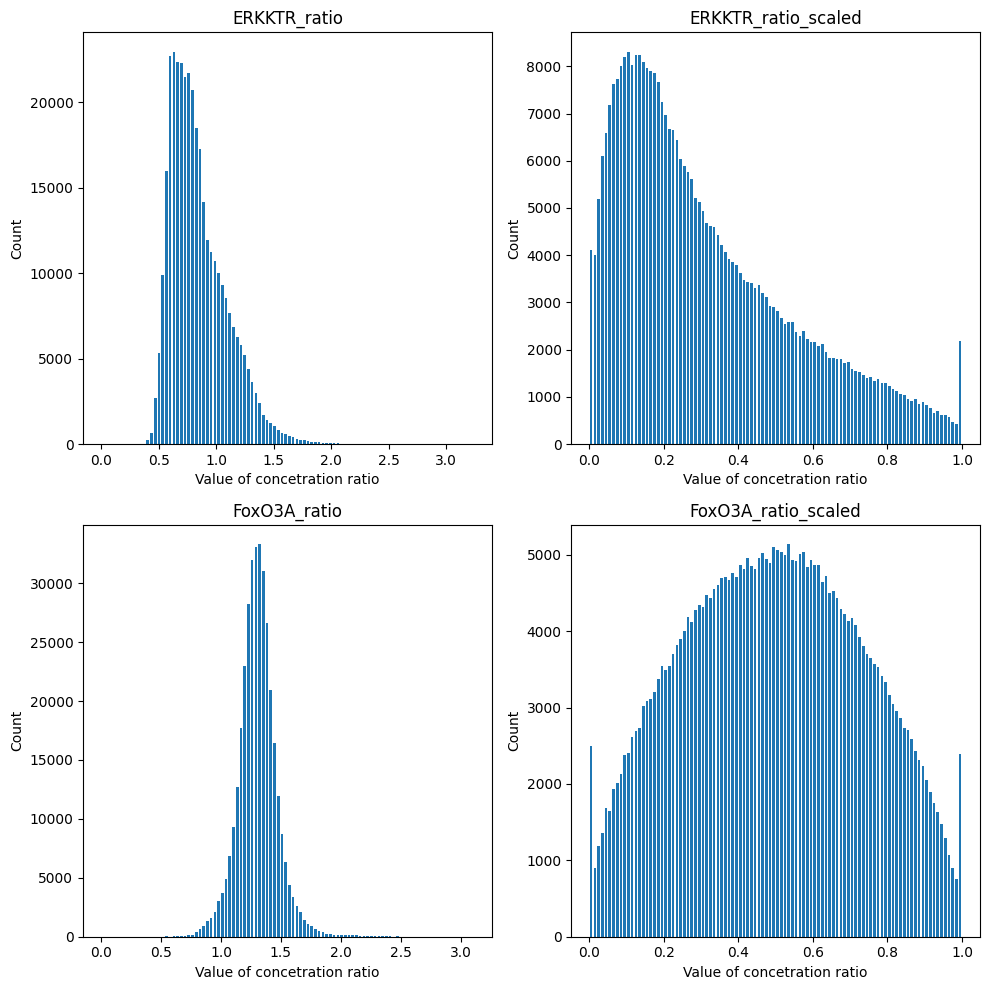

In [16]:
fig, axes = plt.subplots(len(cols_to_scale), len(cols_to_scale), figsize=(5*len(cols_to_scale), 5*len(cols_to_scale)))

for col_axes, col_name in zip(axes, cols_to_scale):
    for ax, col_end in zip(col_axes, ["", "_scaled"]):
        ax.hist(df[f"{col_name}{col_end}"], rwidth=0.7, bins = 100)

        ax.set_title(f"{col_name}{col_end}")
        ax.set_xlabel(f"Value of concetration ratio")
        ax.set_ylabel(f"Count")

fig.tight_layout()

fig.savefig(f"../outputs/change_in_ratios_counts.png")

### First 5 tracks

In [11]:
from scripts.Basic_plotting_ratios import plot_selected_tracks

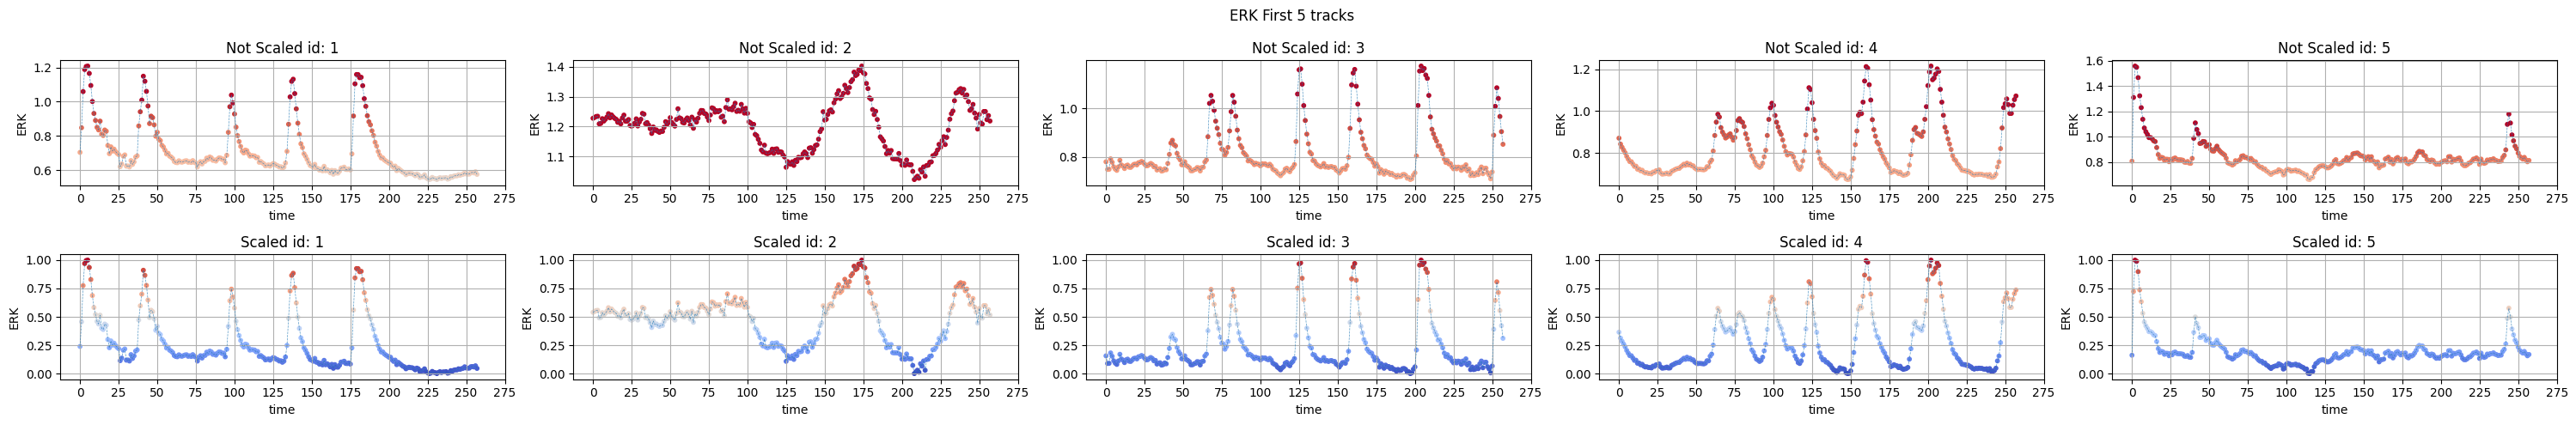

In [12]:
plot_selected_tracks(df, [i for i in range(1, 6)], title = "ERK First 5 tracks", tracked_cols=("ERKKTR_ratio", "ERKKTR_ratio_scaled"))
plt.savefig(f"../outputs/scaled_within_track_id_first_5.png")

### Plotting GIF

In [13]:
from scripts.Basic_plotting_ratios import plot_frame

In [14]:
for time_idx in df.index.get_level_values(0).unique():
    plot_frame(
        frame_idx=time_idx,
        df = df.loc[time_idx],
        experiment_idx=1,
        site_idx=1,
        tracked_ratios=("ERKKTR_ratio_scaled", "FoxO3A_ratio_scaled"),
        cols_names_XY=("objNuclei_Location_Center_X", "objNuclei_Location_Center_Y")
    )
    print(f"{time_idx+1}. Done!")

1. Done!
2. Done!
3. Done!
4. Done!
5. Done!
6. Done!
7. Done!
8. Done!
9. Done!
10. Done!
11. Done!
12. Done!
13. Done!
14. Done!
15. Done!
16. Done!
17. Done!
18. Done!
19. Done!
20. Done!
21. Done!
22. Done!
23. Done!
24. Done!
25. Done!
26. Done!
27. Done!
28. Done!
29. Done!
30. Done!
31. Done!
32. Done!
33. Done!
34. Done!
35. Done!
36. Done!
37. Done!
38. Done!
39. Done!
40. Done!
41. Done!
42. Done!
43. Done!
44. Done!
45. Done!
46. Done!
47. Done!
48. Done!
49. Done!
50. Done!
51. Done!
52. Done!
53. Done!
54. Done!
55. Done!
56. Done!
57. Done!
58. Done!
59. Done!
60. Done!
61. Done!
62. Done!
63. Done!
64. Done!
65. Done!
66. Done!
67. Done!
68. Done!
69. Done!
70. Done!
71. Done!
72. Done!
73. Done!
74. Done!
75. Done!
76. Done!
77. Done!
78. Done!
79. Done!
80. Done!
81. Done!
82. Done!
83. Done!
84. Done!
85. Done!
86. Done!
87. Done!
88. Done!
89. Done!
90. Done!
91. Done!
92. Done!
93. Done!
94. Done!
95. Done!
96. Done!
97. Done!
98. Done!
99. Done!
100. Done!
101. Don

# Making & Saving Gif

In [15]:
import imageio.v3 as imageio

In [ ]:
ims = [imageio.imread(f"../outputs/pics_for_gifs/frame_{time_idx}.png") for time_idx in df.index.get_level_values(0).unique()]

imageio.imwrite(f"../outputs/scaled_within_track_id.gif", ims, fps = 5)